In [36]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [37]:
dairy = pd.read_csv('/kaggle/input/dairy-goods-sales-dataset/dairy_dataset.csv', parse_dates=['Date'])
df = dairy[dairy["Product Name"] == "Milk"]
df.head(2)

,Location,Total Land Area (acres),Number of Cows,Farm Size,Date,Product ID,Product Name,Brand,Quantity (liters/kg),Price per Unit,...,Production Date,Expiration Date,Quantity Sold (liters/kg),Price per Unit (sold),Approx. Total Revenue(INR),Customer Location,Sales Channel,Quantity in Stock (liters/kg),Minimum Stock Threshold (liters/kg),Reorder Quantity (liters/kg)
1,Uttar Pradesh,19.19,44,Large,2021-12-01,1,Milk,Amul,687.48,42.61,...,2021-10-03,2021-10-25,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
15,Kerala,14.97,71,Small,2020-02-22,1,Milk,Mother Dairy,821.52,11.58,...,2020-01-31,2020-02-01,778,8.69,6760.82,Gujarat,Retail,43,89.45,28.11


In [38]:
df['Date']

1      2021-12-01
15     2020-02-22
19     2021-06-15
35     2022-04-28
44     2019-10-23
          ...    
4274   2019-09-07
4299   2020-04-08
4310   2019-11-08
4315   2021-02-07
4324   2019-01-20
Name: Date, Length: 429, dtype: datetime64[ns]

In [39]:
pd.to_datetime(df['Date'])

1      2021-12-01
15     2020-02-22
19     2021-06-15
35     2022-04-28
44     2019-10-23
          ...    
4274   2019-09-07
4299   2020-04-08
4310   2019-11-08
4315   2021-02-07
4324   2019-01-20
Name: Date, Length: 429, dtype: datetime64[ns]

In [40]:
# Group by month
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
monthly_sales = df.groupby("Month")["Approx. Total Revenue(INR)"].sum().reset_index()
monthly_sales.rename(columns={"Approx. Total Revenue(INR)": "Total_Revenue"}, inplace=True)

/tmp/ipykernel_31/1328464247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()


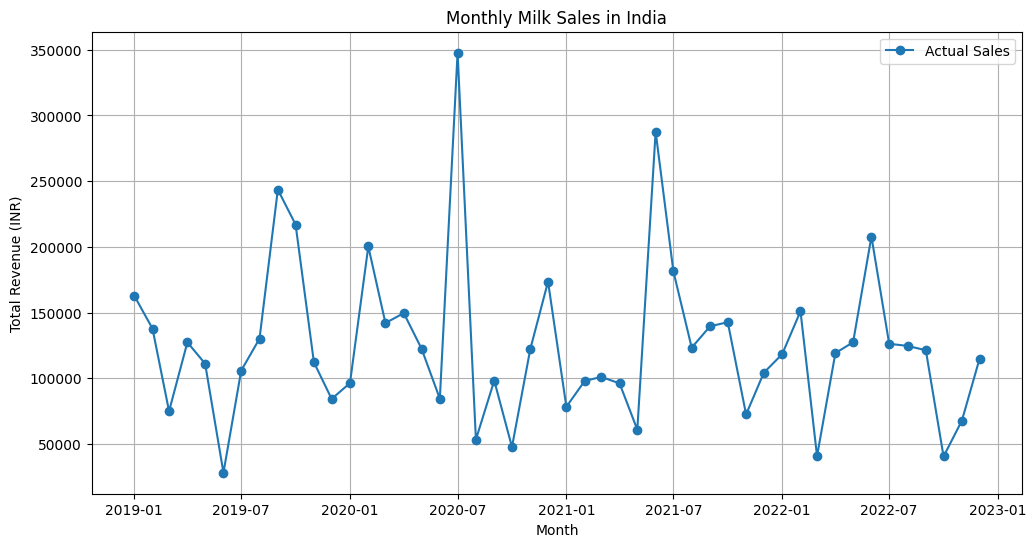

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["Month"], monthly_sales["Total_Revenue"], label="Actual Sales", marker="o")
plt.title("Monthly Milk Sales in India")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.grid(True)
plt.legend()
plt.show()


In [43]:
# Sort by time just in case
monthly_sales = monthly_sales.sort_values("Month")

# Start fresh with original monthly_sales
df = monthly_sales.copy()

# Lag features
df["lag_1"] = df["Total_Revenue"].shift(1)
df["lag_2"] = df["Total_Revenue"].shift(2)
df["lag_3"] = df["Total_Revenue"].shift(3)

# Rolling features
df["rolling_3"] = df["Total_Revenue"].rolling(window=3).mean().shift(1)
df["rolling_6"] = df["Total_Revenue"].rolling(window=6).mean().shift(1)

# Extract month (seasonality)
df["Month_Num"] = (df["Month"] - df["Month"].min()) / np.timedelta64(1, 'm')
df["Month_Index"] = df["uhhh Month"].dt.month

In [44]:
df = df.dropna().reset_index(drop=True)

In [45]:
from sklearn.model_selection import train_test_split

n = int(len(df) * 0.8)
train = df.iloc[:n]
test = df.iloc[n:]

features = ["Month_Num", "Month_Index", "lag_1", "lag_2", "lag_3", "rolling_3", "rolling_6"]
X_train = train[features]
y_train = train["Total_Revenue"]
X_test = test[features]
y_test = test["Total_Revenue"]

In [46]:
from sklearn.linear_model import LinearRegression
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [47]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [48]:
# Shift by 12 months (1 year lag)
baseline_preds = df["Total_Revenue"].shift(12).iloc[n:].values

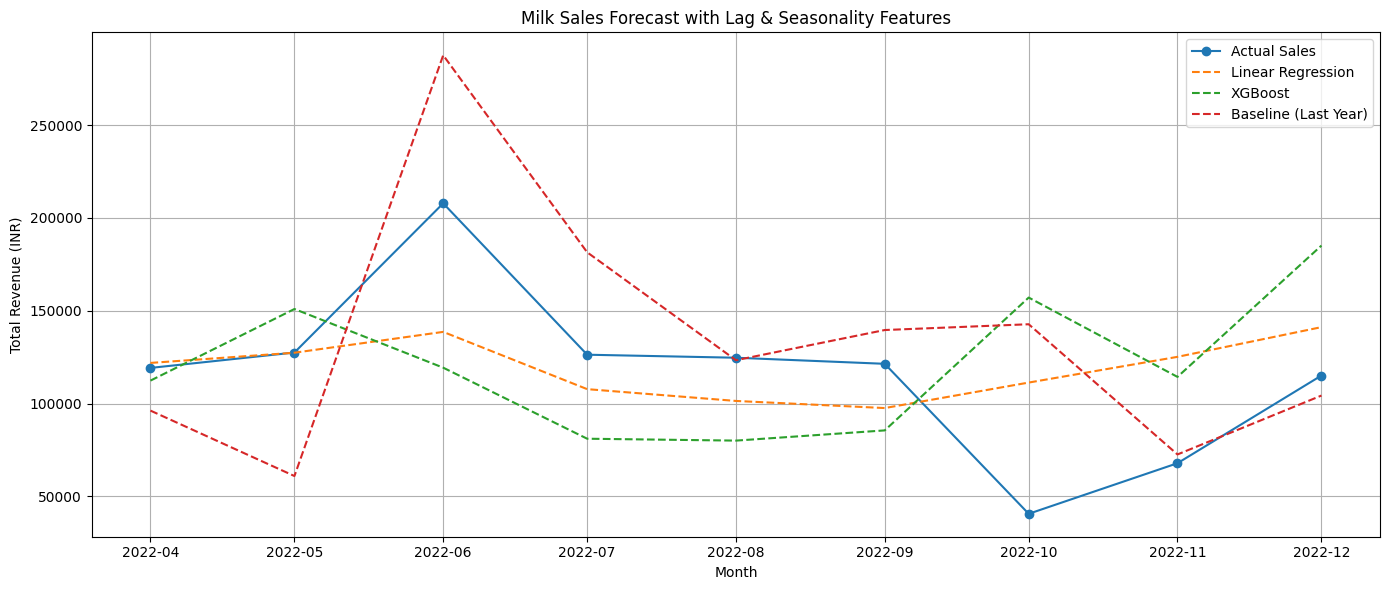

In [53]:
plt.figure(figsize=(14, 6))
plt.plot(test["Month"], y_test, label="Actual Sales", marker='o')
plt.plot(test["Month"], lr_preds, label="Linear Regression", linestyle="--")
plt.plot(test["Month"], xgb_preds, label="XGBoost", linestyle="--")
plt.plot(test["Month"], baseline_preds, label="Baseline (Last Year)", linestyle="--")
plt.title("Milk Sales Forecast with Lag & Seasonality Features")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("milk_sales_just_test.png")
plt.show()


In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

y_test = test["Total_Revenue"]
print(f"Linear Regression MAPE: {mean_absolute_percentage_error(y_test, lr_preds):.2%}")
print(f"XGBoost MAPE: {mean_absolute_percentage_error(y_test, xgb_preds):.2%}")
print(f"Baseline MAPE: {mean_absolute_percentage_error(y_test, baseline_preds):.2%}")

Linear Regression MAPE: 41.11%
XGBoost MAPE: 64.92%
Baseline MAPE: 48.61%


In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Combine true values and predictions
df_plot = df.copy()
df_plot["Set"] = ["Train"] * len(train) + ["Test"] * len(test)
df_plot.loc[test.index, "LR_Pred"] = lr_preds
df_plot.loc[test.index, "XGB_Pred"] = xgb_preds
df_plot.loc[test.index, "Baseline_Pred"] = baseline_preds

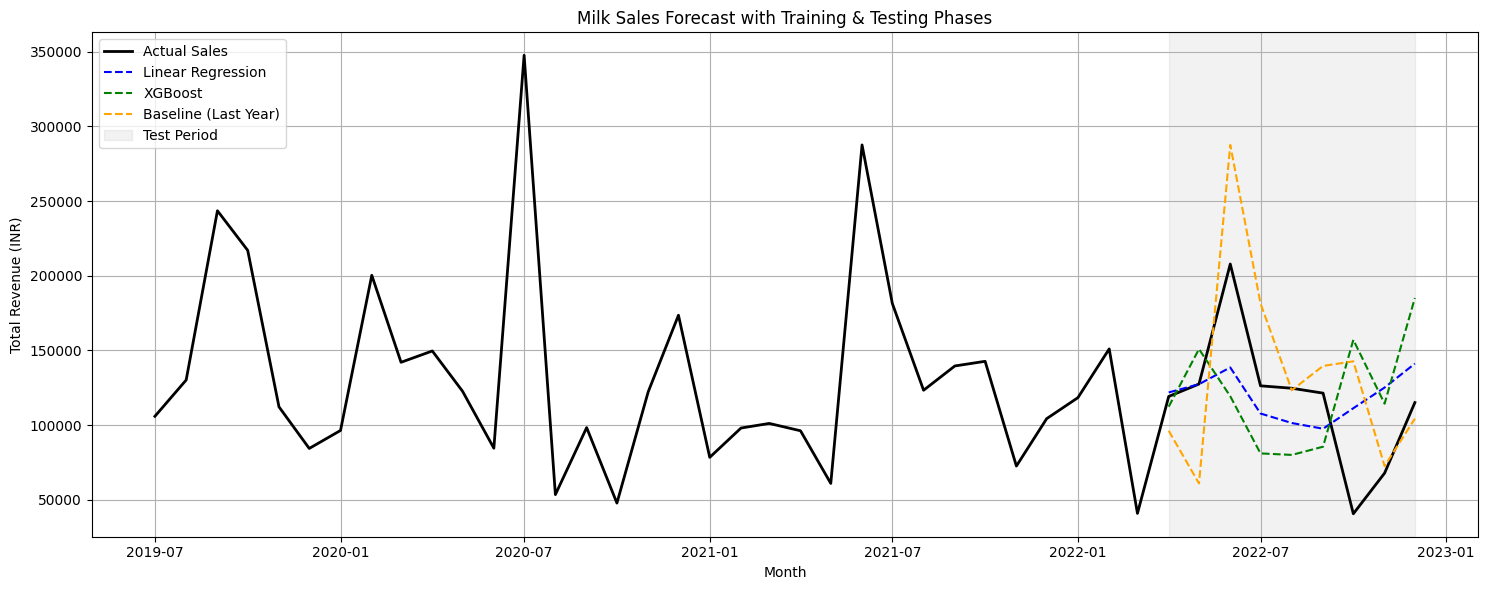

In [52]:
plt.figure(figsize=(15, 6))

# Actual sales
plt.plot(df_plot["Month"], df_plot["Total_Revenue"], label="Actual Sales", color="black", linewidth=2)

# Predictions only for test period
plt.plot(df_plot["Month"], df_plot["LR_Pred"], label="Linear Regression", linestyle="--", color="blue")
plt.plot(df_plot["Month"], df_plot["XGB_Pred"], label="XGBoost", linestyle="--", color="green")
plt.plot(df_plot["Month"], df_plot["Baseline_Pred"], label="Baseline (Last Year)", linestyle="--", color="orange")

# Shade training vs testing
plt.axvspan(df_plot["Month"].iloc[n], df_plot["Month"].iloc[-1], color='grey', alpha=0.1, label="Test Period")

# Labels & legends
plt.title("Milk Sales Forecast with Training & Testing Phases")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('milk_sales_train_and_test.png')
plt.show()
